# 📈 Stock Candlestick Chart (Python)

Using:

✔ mplfinance

✔ plotly

✔ matplotlib

✔ Overlays (MA, EMA, VWAP, Bollinger, RSI…)

✔ Volume bars

✔ Multi-subplot layouts

✔ Indicators + candlesticks

✔ Dark mode / gradient styles

✔ Interactive charts

### Before We Begin (Install mplfinance if needed)

In [1]:
! pip install mplfinance plotly


## SAMPLE OHLC DATA (Used in all variations)

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=60)

# Generate sample price data
price = np.cumsum(np.random.normal(0, 1, 60)) + 100
df = pd.DataFrame({
    "Open": price + np.random.uniform(-1, 1, 60),
    "High": price + np.random.uniform(0, 2, 60),
    "Low": price - np.random.uniform(0, 2, 60),
    "Close": price + np.random.uniform(-1, 1, 60),
    "Volume": np.random.randint(100000, 500000, 60)
}, index=dates)


## Variation 1 — Basic Candlestick Chart (mplfinance)

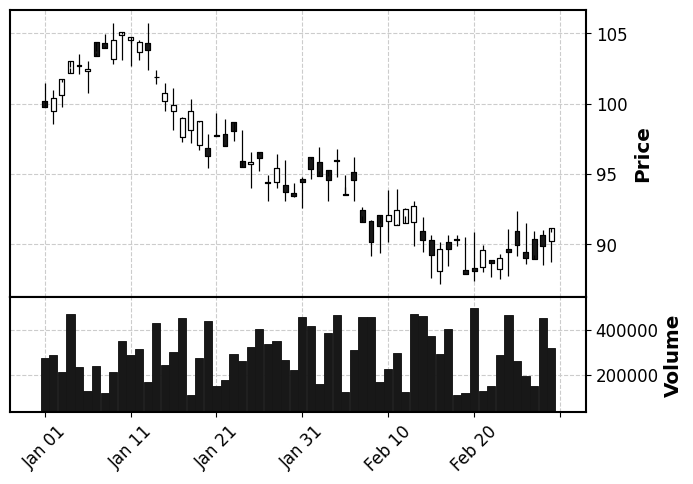

In [3]:
import mplfinance as mpf

mpf.plot(df, type='candle', volume=True, style='classic')


## Variation 2 — Candlestick + Moving Averages

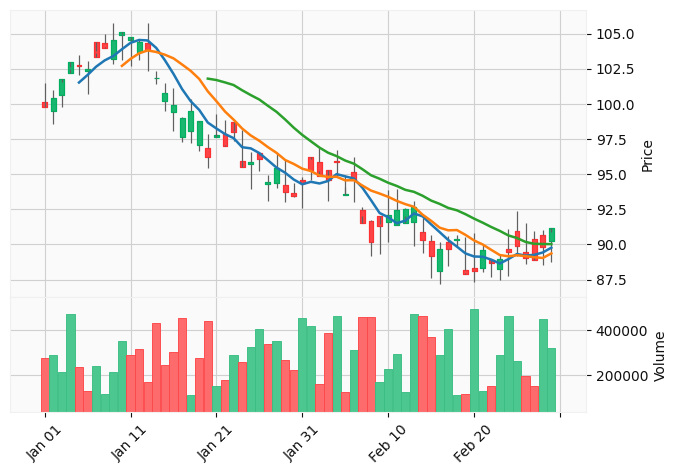

In [4]:
mpf.plot(
    df,
    type='candle',
    mav=(5, 10, 20),
    volume=True,
    style='yahoo'
)


## Variation 3 — Candlestick + Bollinger Bands


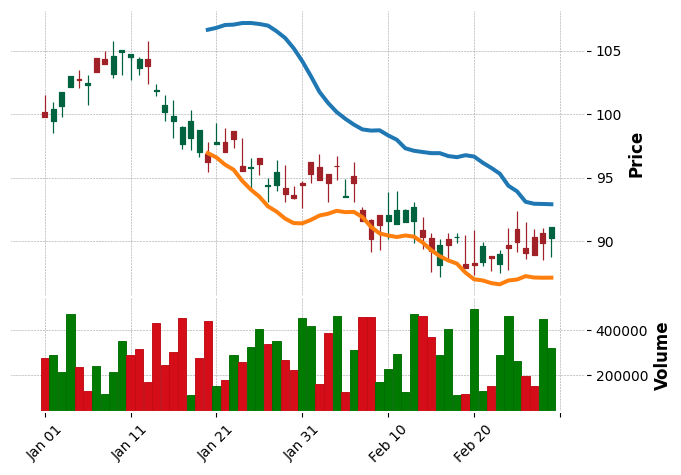

In [5]:
df['MA20'] = df['Close'].rolling(20).mean()
df['BB_up'] = df['MA20'] + 2 * df['Close'].rolling(20).std()
df['BB_dn'] = df['MA20'] - 2 * df['Close'].rolling(20).std()

apds = [
    mpf.make_addplot(df['BB_up']),
    mpf.make_addplot(df['BB_dn']),
]

mpf.plot(df, type='candle', addplot=apds, volume=True, style='charles')


## Variation 4 — Candlestick + RSI Panel

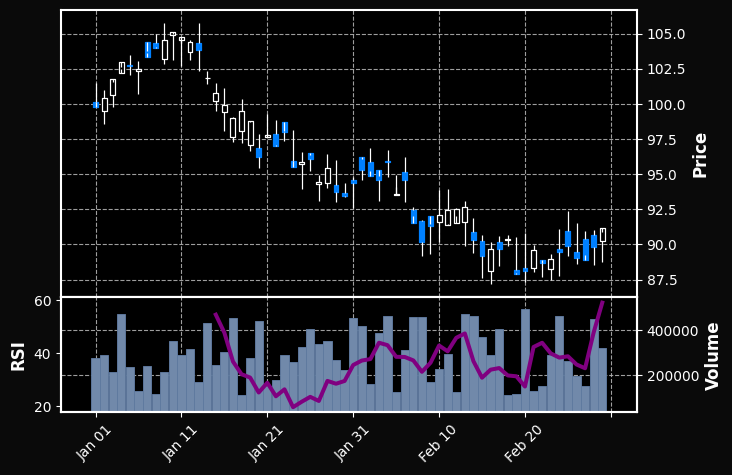

In [6]:
import mplfinance as mpf

def compute_rsi(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0).rolling(period).mean()
    down = -delta.clip(upper=0).rolling(period).mean()
    rs = up / down
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['Close'])

apds = [
    mpf.make_addplot(df['RSI'], panel=1, color='purple', ylabel="RSI")
]

mpf.plot(df, type='candle', volume=True, addplot=apds, style='mike')


## Variation 5 — Dark Mode Candlesticks

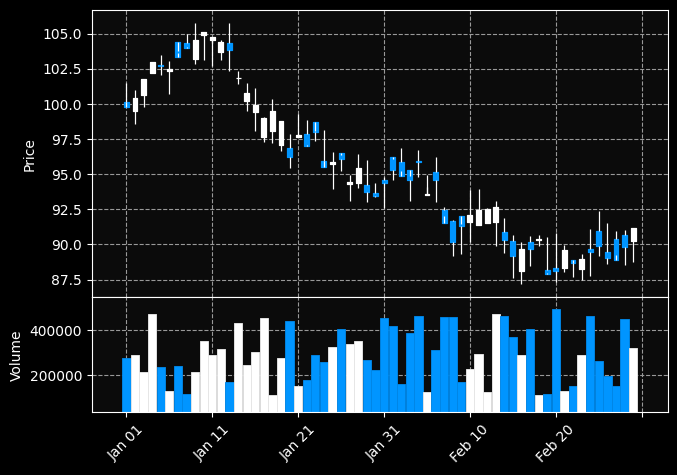

In [7]:
mpf.plot(df, type='candle', volume=True, style='nightclouds')


## Variation 6 — Candlestick + Trendlines

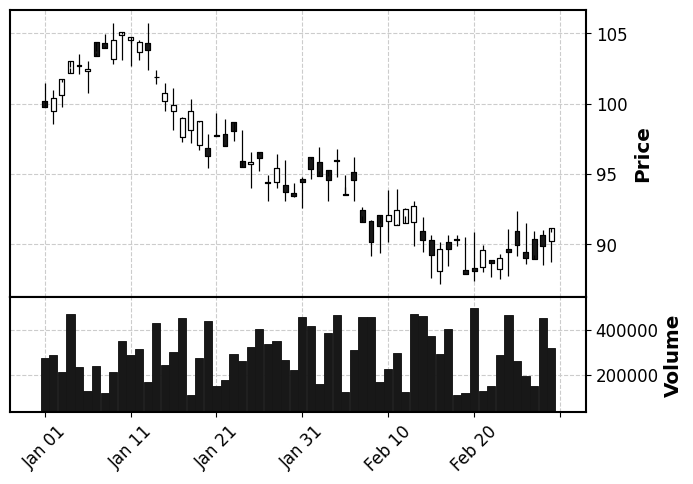

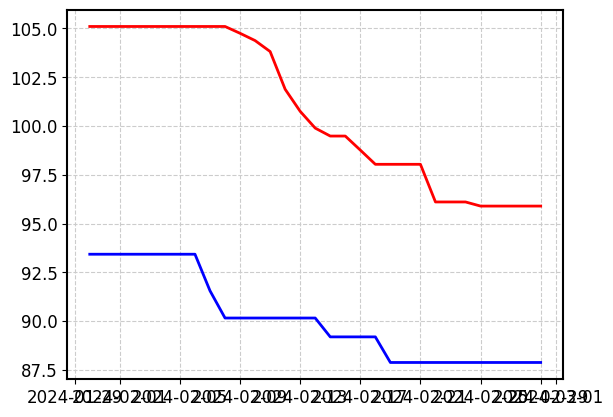

In [8]:
import matplotlib.pyplot as plt

mpf.plot(df, type='candle', volume=True, style='classic')

# Overlay trendlines manually
plt.plot(df.index, df['Close'].rolling(30).max(), color='red')
plt.plot(df.index, df['Close'].rolling(30).min(), color='blue')
plt.show()


## Variation 7 — Candlestick + Custom Colors

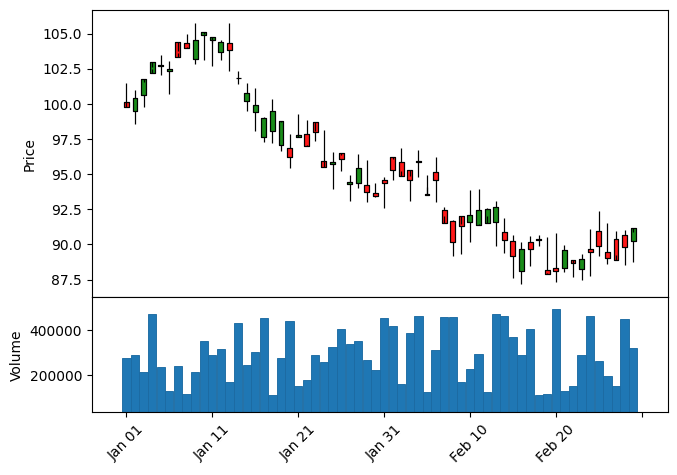

In [9]:
custom_style = mpf.make_mpf_style(
    marketcolors=mpf.make_marketcolors(
        up='green', down='red', wick='black', edge='black'
    )
)

mpf.plot(df, type='candle', volume=True, style=custom_style)


## Variation 8 — Heikin-Ashi Candlestick

C:\Users\NIL\AppData\Local\Temp\ipykernel_27172\336906904.py:11: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\NIL\AppData\Local\Temp\ipykernel_27172\336906904.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy o

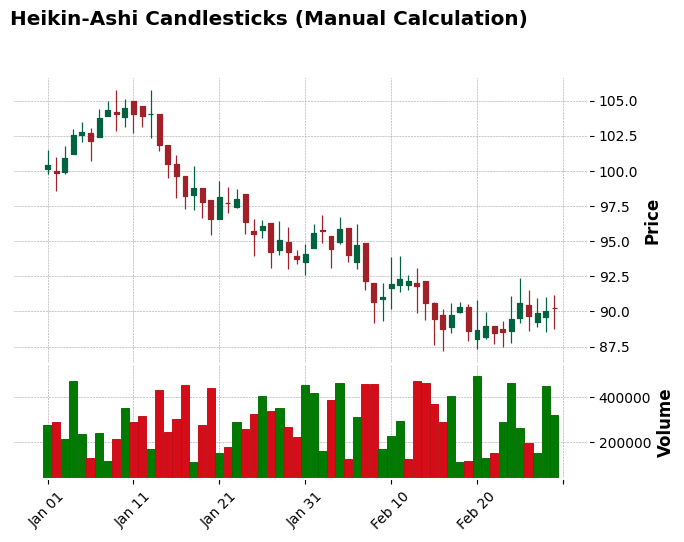

In [18]:
import pandas as pd
import numpy as np
import mplfinance as mpf

ha = df.copy()

# Heikin-Ashi formulas
ha['Close'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

ha['Open'] = (df['Open'].shift(1) + df['Close'].shift(1)) / 2
ha['Open'].iloc[0] = df['Open'].iloc[0]

ha['High'] = df[['High','Open','Close']].max(axis=1)
ha['Low']  = df[['Low','Open','Close']].min(axis=1)

mpf.plot(
    ha,
    type='candle',
    volume=True,
    style='charles',
    title="Heikin-Ashi Candlesticks (Manual Calculation)"
)


### Bonus — Heikin-Ashi + MA (Looks like TradingView)

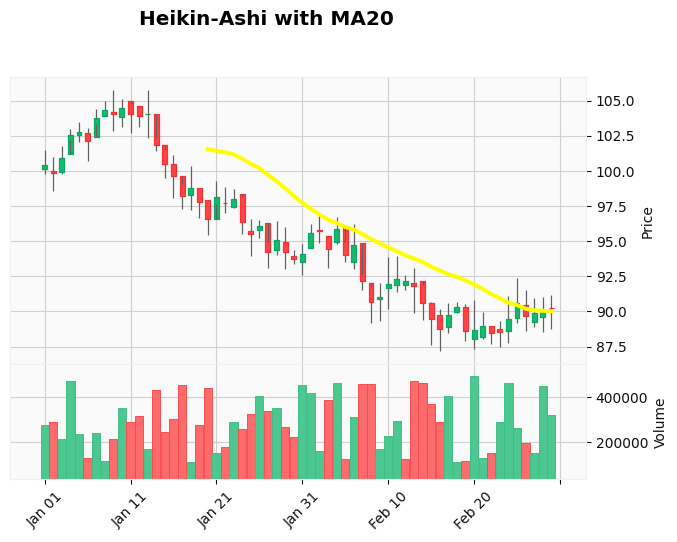

In [19]:
ha['MA20'] = ha['Close'].rolling(20).mean()

ap = [mpf.make_addplot(ha['MA20'], color='yellow')]

mpf.plot(
    ha,
    type='candle',
    volume=True,
    addplot=ap,
    style='yahoo',
    title='Heikin-Ashi with MA20'
)


## Variation 9 — Renko Candlestick

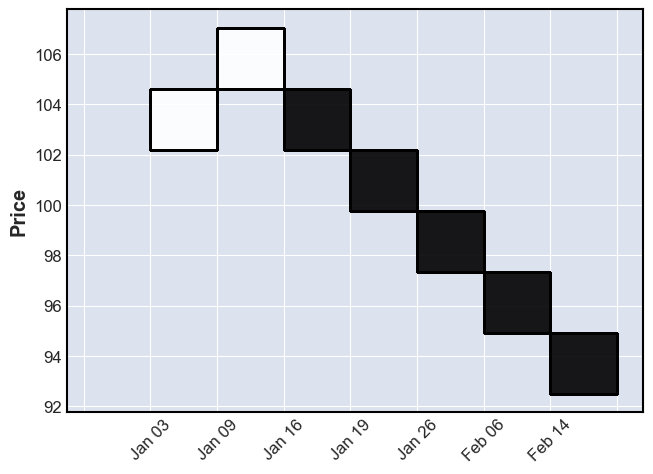

In [11]:
mpf.plot(df, type='renko', style='default')


## Variation 10 — Candlestick with Volume Overlay (Plotly Interactive)

In [12]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close']
    )
])

fig.update_layout(title="Interactive Candlestick Chart")
fig.show()


## Variation 11 — Candlestick + Volume Bars

In [13]:
fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close']
    )
)

fig.add_trace(
    go.Bar(x=df.index, y=df['Volume'], marker_color='lightblue', yaxis='y2')
)

fig.update_layout(
    yaxis2=dict(overlaying='y', side='right', range=[0, df['Volume'].max()*3]),
    title="Candlestick with Volume Bars"
)

fig.show()


## Variation 12 — Candlestick + EMA + VWAP + MACD + RSI (Full Indicator Dashboard)

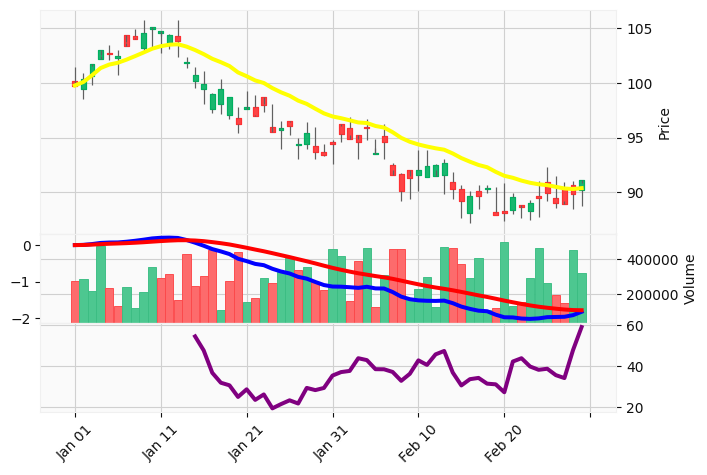

In [15]:
# Compute Indicators
df['EMA20'] = df['Close'].ewm(span=20).mean()

delta = df['Close'].diff()
df['MACD'] = df['Close'].ewm(12).mean() - df['Close'].ewm(26).mean()
df['Signal'] = df['MACD'].ewm(9).mean()

df['RSI'] = compute_rsi(df['Close'])

ap = [
    mpf.make_addplot(df['EMA20'], color='yellow'),
    mpf.make_addplot(df['MACD'], panel=1, color='blue'),
    mpf.make_addplot(df['Signal'], panel=1, color='red'),
    mpf.make_addplot(df['RSI'], panel=2, color='purple')
]

mpf.plot(df, type='candle', addplot=ap, volume=True, style='yahoo')


## Variation 13 — Multi-Stock Candlestick Grid

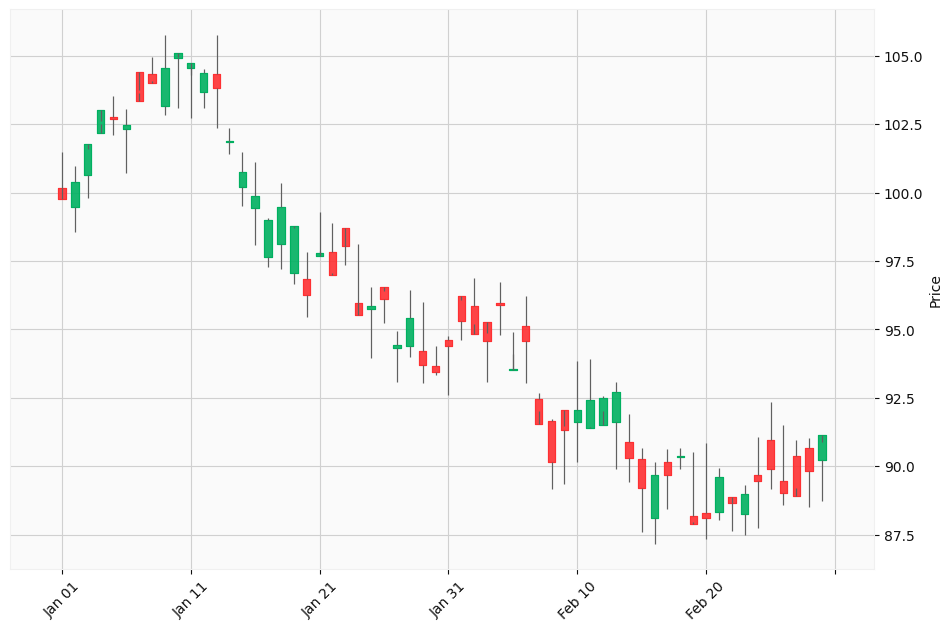

In [16]:
fig, axes = mpf.plot(
    df, type='candle', returnfig=True,
    figsize=(12,8), style='yahoo'
)


## 🔥 Animated Candlestick Chart → Exported as GIF

(using matplotlib, mplfinance, and imageio)

This produces a smooth, frame-by-frame animation like TradingView’s bar replay.

You can run this code in any Python environment.

### Install Required Libraries

In [24]:
# ! pip install mplfinance imageio


### Step 1 — Generate Sample OHLC Data

In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=80)

price = np.cumsum(np.random.normal(0, 1, 80)) + 100

df = pd.DataFrame({
    'Open':  price + np.random.uniform(-1, 1, 80),
    'High':  price + np.random.uniform(0, 2, 80),
    'Low':   price - np.random.uniform(0, 2, 80),
    'Close': price + np.random.uniform(-1, 1, 80),
    'Volume': np.random.randint(100000, 300000, 80)
}, index=dates)


### Step 2 — Create Frames for the Animation

In [22]:
import mplfinance as mpf
import os

# Folder to store frames
os.makedirs("frames", exist_ok=True)

for i in range(10, len(df)):
    sub = df.iloc[:i]

    mpf.plot(
        sub,
        type='candle',
        volume=True,
        style='yahoo',
        savefig=f"frames/frame_{i:03d}.png",
        figsize=(10,6)
    )


### Step 3 — Convert Frames into a GIF

In [23]:
import imageio
import os

frames = []
files = sorted(os.listdir("frames"))

for file in files:
    if file.endswith(".png"):
        frames.append(imageio.imread(f"frames/{file}"))

imageio.mimsave("animated_candlestick.gif", frames, fps=8)


C:\Users\NIL\AppData\Local\Temp\ipykernel_27172\867372520.py:9: DeprecationWarning:

Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.

